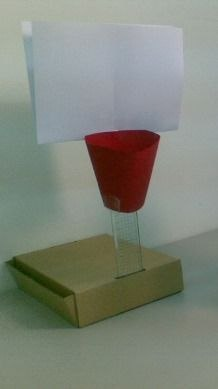

In [6]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

image = cv2.imread('/content/Bucket.jpg')
#redrgb=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
cv2_imshow(image)
cv2.waitKey(0)
cv2.destroyAllWindows()


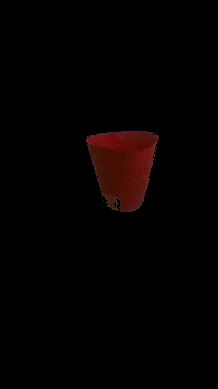

In [7]:
upperred= np.array([50,45,255])
lowerred=np.array([0,0,40])
mask = cv2.inRange(image,lowerred, upperred)
maskcolour= cv2.bitwise_and(image,image,mask=mask)

cv2_imshow(maskcolour)

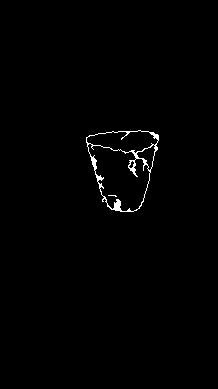

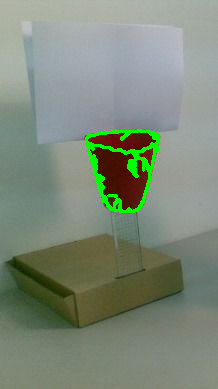

In [38]:
blurmask = cv2.bilateralFilter(maskcolour,3,3,2)
h,w,c= image.shape
blurmask2= cv2.GaussianBlur(maskcolour,(3,3),sigmaX=1,sigmaY=0.1)
edgeblurmask= cv2.Canny(blurmask,0,80)

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
edges_cleaned = cv2.morphologyEx(edgeblurmask, cv2.MORPH_CLOSE, kernel)
cv2_imshow(edges_cleaned)
cv2_imshow(image)

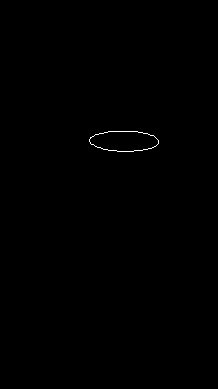

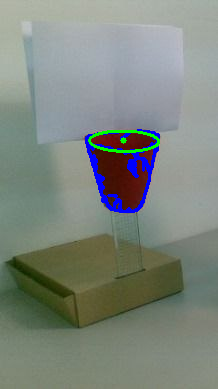

In [37]:
cont,heirachy= cv2.findContours(edges_cleaned,cv2.RETR_TREE,cv2.CHAIN_APPROX_SIMPLE)
sortedcont= sorted(cont,key=cv2.contourArea,reverse=True)
temp_img = image.copy()
h,w,c= image.shape
cv2.drawContours(temp_img,cont,-1,(255,0,0),2)
EllipseData=cv2.fitEllipse(sortedcont[2])
cv2.ellipse(temp_img, EllipseData,(0,255,0),2)
img = np.zeros((h, w, c), dtype=np.uint8)
cv2.ellipse(img,EllipseData,(255,255,255),1)
cv2.circle(temp_img,(int(EllipseData[0][0]),int(EllipseData[0][1])),3,(0,255,0),-1)
cv2_imshow(img)
cv2_imshow(temp_img)
cv2.waitKey()
cv2.destroyAllWindows()